<a href="https://colab.research.google.com/github/Pedro4Albuquerque/am-t4-s1a2026t2/blob/main/MultiNeuralCensus0609.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Naive Bayes | Digest GaussianNB [Fase 1 - census_data]

## Importar dados do Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Bibliotecas de Python

In [2]:
!pip -q install plotly
!pip -q install yellowbrick

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Carregar Digest de base_census

In [4]:
import pickle

In [5]:
with open('/content/drive/MyDrive/am-t4/census.pkl', 'rb') as f:
  X_census_treinamento, Y_census_treinamento, X_census_teste, Y_census_teste = pickle.load(f)

In [6]:
X_census_treinamento.shape, Y_census_treinamento.shape

((27676, 108), (27676,))

In [7]:
X_census_teste.shape, Y_census_teste.shape

((4885, 108), (4885,))

In [8]:
from sklearn.naive_bayes import GaussianNB

In [9]:
naive_census_data = GaussianNB()
naive_census_data.fit(X_census_treinamento, Y_census_treinamento)

GaussianNB()

## Criando base Previsora

In [10]:
census_predict = naive_census_data.predict(X_census_teste)

In [11]:
census_predict

array([' >50K', ' >50K', ' >50K', ..., ' <=50K', ' >50K', ' >50K'],
      dtype='<U6')

In [12]:
Y_census_teste

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [14]:
accuracy_score(Y_census_teste, census_predict)

0.4767656090071648

In [15]:
confusion_matrix(Y_census_teste, census_predict)

array([[1172, 2521],
       [  35, 1157]])

In [16]:
from yellowbrick.classifier import ConfusionMatrix

0.4767656090071648

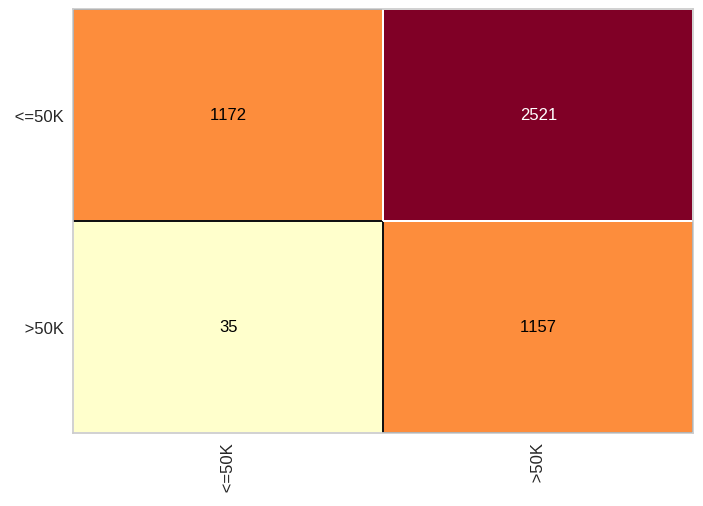

In [17]:
cm_census = ConfusionMatrix(naive_census_data)
cm_census.fit(X_census_treinamento, Y_census_treinamento)
cm_census.score(X_census_teste, Y_census_teste)

# Pipeline Arvore de Decisão | Treemap Base [Fase 1 - census_data]

In [18]:
from sklearn.tree import DecisionTreeClassifier

In [19]:
arvore_census_data = DecisionTreeClassifier(criterion='entropy', random_state=0)
arvore_census_data.fit(X_census_treinamento, Y_census_treinamento)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [20]:
DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion="entropy",
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0,
                       random_state=0, splitter='best')

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [21]:
previsoes_arvore = arvore_census_data.predict(X_census_teste)

In [22]:
previsoes_arvore

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [23]:
Y_census_teste

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

## Pipeline Medicões Harmonicas  | Treemap Base [Fase 2 - census_data]

In [24]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [25]:
accuracy_score(Y_census_teste, previsoes_arvore)

0.8104401228249745

0.8104401228249745

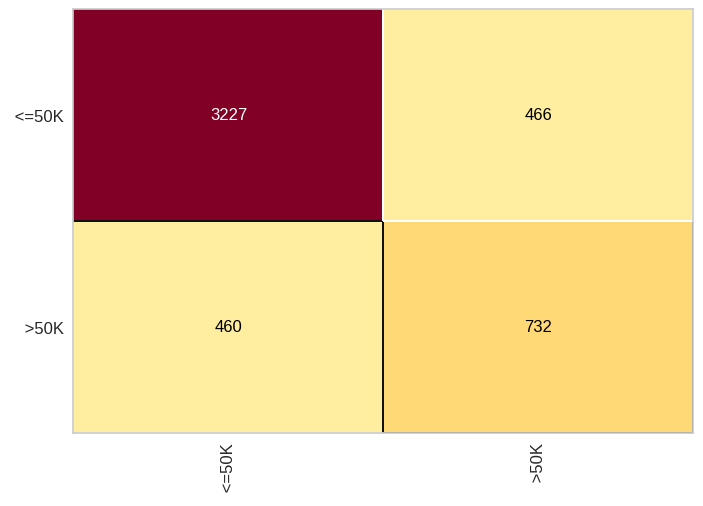

In [26]:
from yellowbrick.classifier import ConfusionMatrix
cm_tree = ConfusionMatrix(arvore_census_data)
cm_tree.fit(X_census_treinamento, Y_census_treinamento)
cm_tree.score(X_census_teste, Y_census_teste)

In [27]:
print(classification_report(Y_census_teste, previsoes_arvore))

              precision    recall  f1-score   support

       <=50K       0.88      0.87      0.87      3693
        >50K       0.61      0.61      0.61      1192

    accuracy                           0.81      4885
   macro avg       0.74      0.74      0.74      4885
weighted avg       0.81      0.81      0.81      4885



# Pipeline Rondom Forest | Digest Pickle [Fase 1 - census Base]

In [28]:
from sklearn.ensemble import RandomForestClassifier

In [29]:
random_census = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
random_census.fit(X_census_treinamento, Y_census_treinamento)
RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='entropy', max_depth=None, max_features='auto',
                       min_impurity_decrease=0.0, min_samples_split=None,
                       min_samples_leaf=1, min_weight_fraction_leaf=0.0, n_estimators=10,
                       n_jobs=None, oob_score=False, random_state=0, verbose=0, warm_start=False)

RandomForestClassifier(criterion='entropy', max_features='auto',
                       min_samples_split=None, n_estimators=10, random_state=0)

In [30]:
previsores_random = random_census.predict(X_census_teste)
previsores_random

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

## Criando base Previsora

In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [32]:
accuracy_score(Y_census_teste, previsores_random)

0.8390992835209826

In [33]:
confusion_matrix(Y_census_teste, previsores_random)

array([[3419,  274],
       [ 512,  680]])

In [34]:
from yellowbrick.classifier import ConfusionMatrix

0.8390992835209826

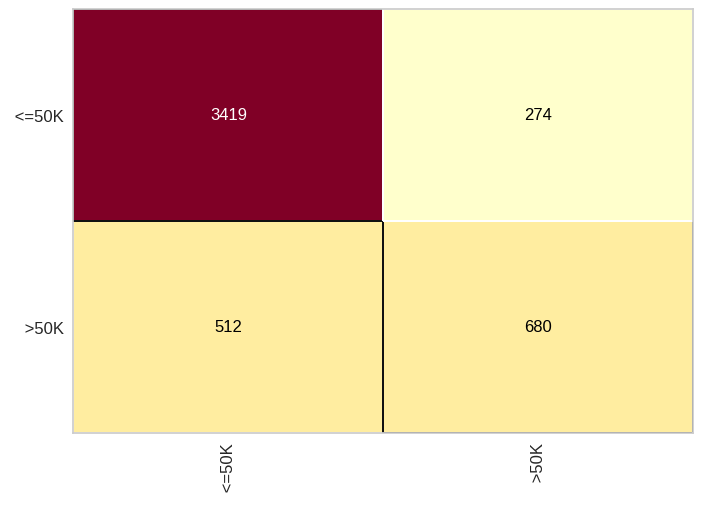

In [35]:
cm_census = ConfusionMatrix(random_census)
cm_census.fit(X_census_treinamento, Y_census_treinamento)
cm_census.score(X_census_teste, Y_census_teste)

In [36]:
print(classification_report(Y_census_teste, previsores_random))

              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90      3693
        >50K       0.71      0.57      0.63      1192

    accuracy                           0.84      4885
   macro avg       0.79      0.75      0.77      4885
weighted avg       0.83      0.84      0.83      4885



# Pipeline Regressão | Digest [Fase 1 census Base]

In [37]:
from sklearn.linear_model import LogisticRegression

In [38]:
regressao_census = LogisticRegression(random_state=1)
regressao_census.fit(X_census_treinamento, Y_census_treinamento)

LogisticRegression(random_state=1)

In [39]:
LogisticRegression(C=1.0,class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty ='l2',
                   random_state=1, solver='lbfgs', tol =0.0001, verbose=0,
                   warm_start=False)

LogisticRegression(multi_class='auto', random_state=1)

In [40]:
regressao_previsoes = regressao_census.predict(X_census_teste)
regressao_previsoes

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [41]:
accuracy_score(Y_census_teste, regressao_census.predict(X_census_teste))

0.8497441146366428

In [42]:
from yellowbrick.classifier import ConfusionMatrix

0.8497441146366428

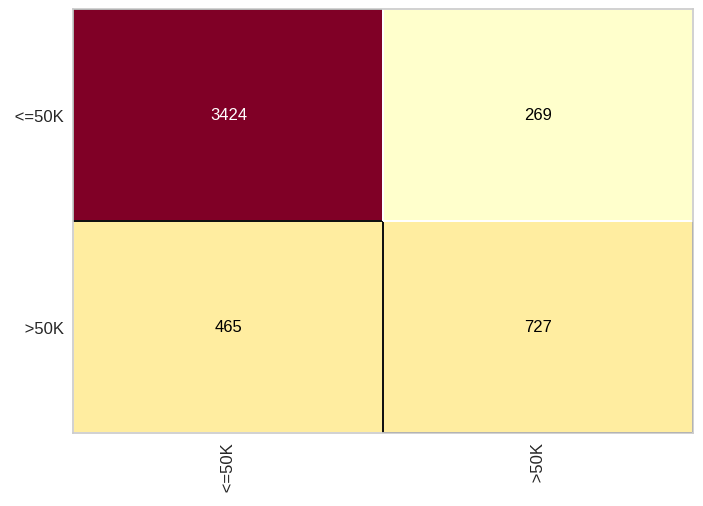

In [43]:
cm_census_reg = ConfusionMatrix(regressao_census)
cm_census_reg.fit(X_census_treinamento, Y_census_treinamento)
cm_census_reg.score(X_census_teste, Y_census_teste)

In [44]:
print(classification_report(Y_census_teste, regressao_census.predict(X_census_teste)))

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      3693
        >50K       0.73      0.61      0.66      1192

    accuracy                           0.85      4885
   macro avg       0.81      0.77      0.78      4885
weighted avg       0.84      0.85      0.84      4885

